In [11]:
# Daniel Chang
# M178 Final Project

In [ ]:
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt

# Parameters

# Binding + dissociation
k_a = 0.1      # NFkB + IkB <-> complex
k_d = 0.0006   # NFkB:IkB -> NFkB + IkB

# Degradation
r   = 0.01     # IKK-mediated degradation rate
g   = 0.012    # constitutive IkB degradation

# Promoter binding
f_a = 10       # NFkB binding to promoter
f_d = 200      # NFkB unbinding from promoter

# fast loop = alpha, slow loop = epsilon
a1 = 0.00185   # IkBa synthesis from free promoter
b1 = 5.0       # IkBa synthesis from NFkB-bound promoter

a2 = 0.005     # IkBe synthesis from free promoter  
b2 = 10.0      # IkBe synthesis from NFkB-bound promoter

# IKK settings 
IKK_on_time  = 0
IKK_off_time = 1000
IKK_amplitude = 2.2

t_index = None
soln_hist = None

# Delay helper functions

def delay_prIKBa(t_search):
    #Return delayed prIKBa value at time t_search
    global t_index, soln_hist
    idx = np.argmin(np.abs(t_search - t_index))
    return soln_hist[idx, 3]   

def delay_NFKB_prIKBa(t_search):
    # Return delayed NFKB:prIKBa value at time t_search
    global t_index, soln_hist
    idx = np.argmin(np.abs(t_search - t_index))
    return soln_hist[idx, 4] 

def delay_prIKBe(t_search):
    # Return delayed prIKBe value at time t_search 
    global t_index, soln_hist
    idx = np.argmin(np.abs(t_search - t_index))
    return soln_hist[idx, 7]  

def delay_NFKB_prIKBe(t_search):
    # Return delayed NFKB:prIKBe value at time t_search
    global t_index, soln_hist
    idx = np.argmin(np.abs(t_search - t_index))
    return soln_hist[idx, 8] 

# NFkB–IkBa–IkBe delay model
# states = [NFKB, IKBa, NFKB_IKBa, prIKBa, NFKB_prIKBa, IKBe, NFKB_IKBe, prIKBe, NFKB_prIKBe]


def NFKB_model(states, t, IKK_on, IKK_off, IKK_amp):
    global k_a, k_d, r, g, f_a, f_d, a1, b1, a2, b2

    # Unpack state variables
    NFKB          = states[0]
    IKBa          = states[1]
    NFKB_IKBa     = states[2]
    prIKBa        = states[3]
    NFKB_prIKBa   = states[4]
    IKBe          = states[5]
    NFKB_IKBe     = states[6]
    prIKBe        = states[7]
    NFKB_prIKBe   = states[8]

    # Delayed promoter states (alpha & epsilon)
    prIKBa_tau      = delay_prIKBa(t)
    NFKB_prIKBa_tau = delay_NFKB_prIKBa(t)
    prIKBe_tau      = delay_prIKBe(t)
    NFKB_prIKBe_tau = delay_NFKB_prIKBe(t)

    # IKK activation
    if t > IKK_on and t < IKK_off:
        IKK = IKK_amp
    else:
        IKK = 0.0

    # odes

    # dNFKB/dt (free NFkB)
    NFKB_prime = (
        -k_a * NFKB * IKBa + k_d * NFKB_IKBa + r * NFKB_IKBa * IKK
        -k_a * NFKB * IKBe + k_d * NFKB_IKBe + r * NFKB_IKBe * IKK
        -f_a * NFKB * prIKBa + f_d * NFKB_prIKBa
        -f_a * NFKB * prIKBe + f_d * NFKB_prIKBe
    )

    # dIKBa/dt
    IKBa_prime = (
        -k_a * NFKB * IKBa + k_d * NFKB_IKBa
        + a1 * prIKBa_tau + b1 * NFKB_prIKBa_tau
        - g * IKBa - r * IKK * IKBa
    )

    # dIKBe/dt
    IKBe_prime = (
        -k_a * NFKB * IKBe + k_d * NFKB_IKBe
        + a2 * prIKBe_tau + b2 * NFKB_prIKBe_tau
        - g * IKBe - r * IKK * IKBe
    )

    # d(NFKB:IKBa)/dt
    NFKB_IKBa_prime = k_a * NFKB * IKBa - k_d * NFKB_IKBa - r * NFKB_IKBa * IKK

    # d(NFKB:IKBe)/dt
    NFKB_IKBe_prime = k_a * NFKB * IKBe - k_d * NFKB_IKBe - r * NFKB_IKBe * IKK

    # d(prIKBa)/dt
    prIKBa_prime = -f_a * NFKB * prIKBa + f_d * NFKB_prIKBa

    # d(prIKBe)/dt
    prIKBe_prime = -f_a * NFKB * prIKBe + f_d * NFKB_prIKBe

    # d(NFKB:prIKBa)/dt
    NFKB_prIKBa_prime = f_a * NFKB * prIKBa - f_d * NFKB_prIKBa

    # d(NFKB:prIKBe)/dt
    NFKB_prIKBe_prime = f_a * NFKB * prIKBe - f_d * NFKB_prIKBe

    return [
        NFKB_prime,
        IKBa_prime,
        NFKB_IKBa_prime,
        prIKBa_prime,
        NFKB_prIKBa_prime,
        IKBe_prime,
        NFKB_IKBe_prime,
        prIKBe_prime,
        NFKB_prIKBe_prime,
    ]

# Run one delay simulation (tau windows together)

def run_delay_sim(tau=25, iterations=20):
    global t_index, soln_hist

    # Initial conditions
    NFKB_0        = 100.0
    IKBa_0        = 0.0
    NFKB_IKBa_0   = 0.0
    prIKBa_0      = 1.0
    NFKB_prIKBa_0 = 0.0

    IKBe_0        = 0.0
    NFKB_IKBe_0   = 0.0
    prIKBe_0      = 1.0
    NFKB_prIKBe_0 = 0.0

    states0 = [
        NFKB_0,
        IKBa_0,
        NFKB_IKBa_0,
        prIKBa_0,
        NFKB_prIKBa_0,
        IKBe_0,
        NFKB_IKBe_0,
        prIKBe_0,
        NFKB_prIKBe_0,
    ]

    # Storage for full trajectory
    t_final = np.array([])
    soln_final = np.empty((0, 9))

    # Initial history: constant at initial condition
    t_index = np.linspace(0, tau, 1001)
    soln_hist = np.tile(states0, (1001, 1))

    for i in range(iterations):
        t_index = np.linspace(0, tau, 1001)
        solution = odeint(
            NFKB_model,
            states0,
            t_index,
            args=(IKK_on_time, IKK_off_time, IKK_amplitude),
        )

       
        t_final = np.append(t_final, (t_index[0:1000] + i * tau))
        soln_final = np.vstack((soln_final, solution[0:1000, :]))

        states0 = solution[1000, :]
        soln_hist = solution

    return t_final, soln_final

# Helper: measure oscillation amplitude of NFkB

def nfkb_oscillation_amplitude(t, soln, tau, windows_to_use=3):
    # peak to peak amplitudes of NFkB
    NFKB = soln[:, 0]
    t_max = t.max()
    t_min_use = t_max - windows_to_use * tau
    mask = t >= t_min_use
    N_seg = NFKB[mask]
    if N_seg.size == 0:
        return 0.0
    return N_seg.max() - N_seg.min()

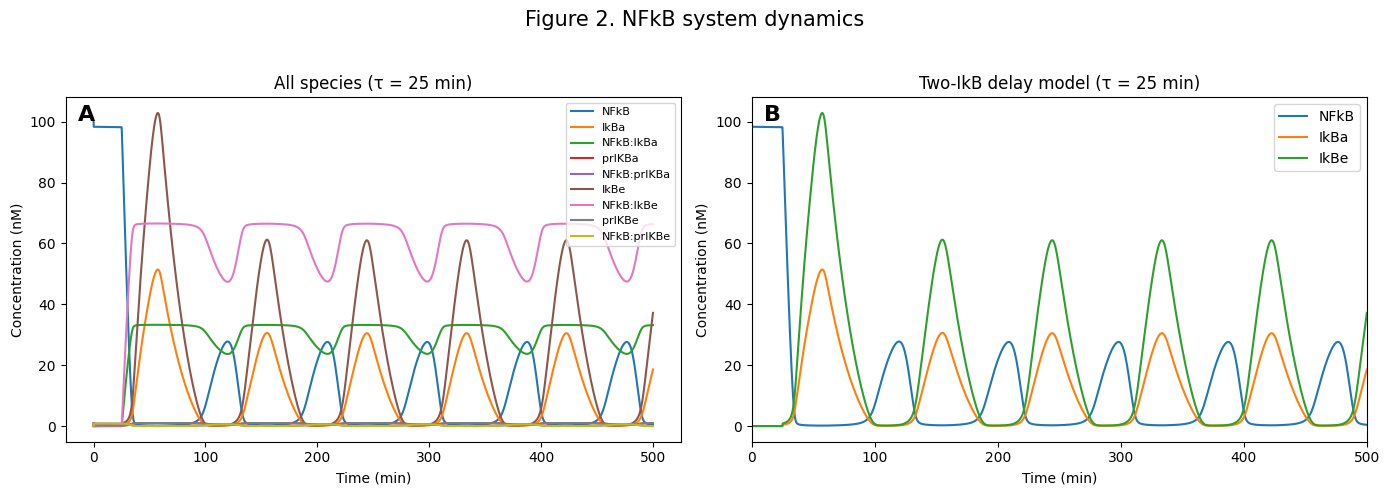

In [9]:
# FIGURE 2: A = all species | B = NFkB, IkBa, IkBe

tau_base = 25
t, sol = run_delay_sim(tau=tau_base, iterations=20)

# A: all 9 species
labels = [
    "NFkB", "IkBa", "NFkB:IkBa", "prIKBa", "NFkB:prIKBa",
    "IkBe", "NFkB:IkBe", "prIKBe", "NFkB:prIKBe"
]

# B: NFkB, IkBA, IkBE
NFKB = sol[:, 0]
IKBa = sol[:, 1]
IKBe = sol[:, 5]

fig2, (axA, axB) = plt.subplots(1, 2, figsize=(14, 5))

# Panel A: All species
for i in range(sol.shape[1]):
    axA.plot(t, sol[:, i], label=labels[i])

axA.set_xlabel("Time (min)")
axA.set_ylabel("Concentration (nM)")
axA.set_title(f"All species (τ = {tau_base} min)")
axA.legend(fontsize=8, loc="upper right")
axA.text(0.02, 0.93, "A", transform=axA.transAxes,
         fontsize=16, fontweight="bold")


# Panel B: NFkB, IkBa, IkBe
axB.plot(t, NFKB, label="NFkB")
axB.plot(t, IKBa, label="IkBa")
axB.plot(t, IKBe, label="IkBe")
axB.set_xlabel("Time (min)")
axB.set_ylabel("Concentration (nM)")
axB.set_title(f"Two-IkB delay model (τ = {tau_base} min)")
axB.set_xlim(0, 500) 
axB.legend()
axB.text(0.02, 0.93, "B", transform=axB.transAxes,
         fontsize=16, fontweight="bold")

fig2.suptitle("Figure 2. NFkB system dynamics", fontsize=15)
fig2.tight_layout(rect=[0, 0, 1, 0.95])
fig2.savefig("figure2_combined.png", dpi=300, bbox_inches="tight")
plt.show()




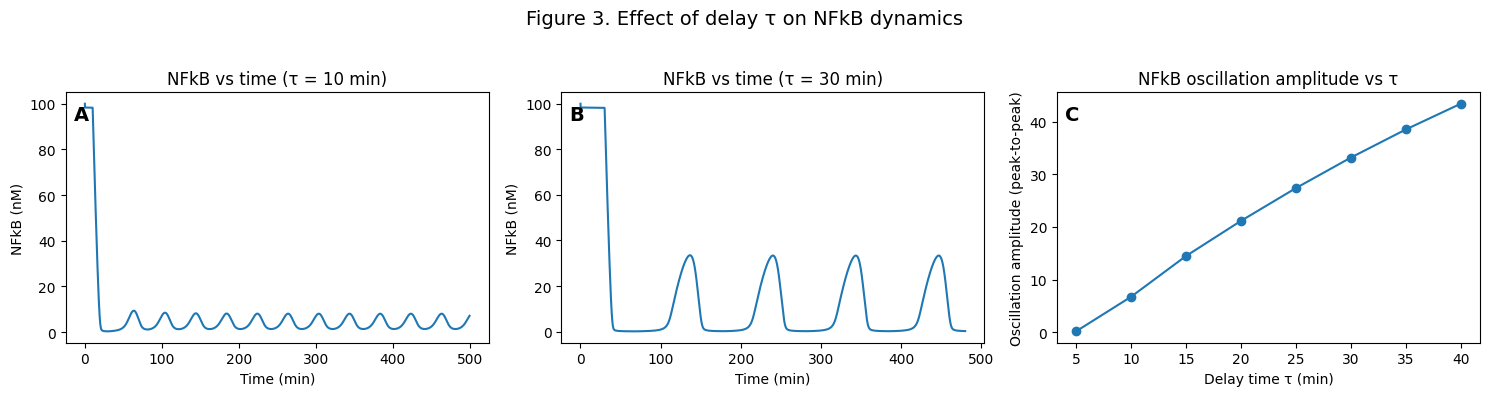

In [11]:
# FIGURE 3 (A–C): Effect of delay tau
# 3A: NFkB time series for lower tau value
# 3B: NFkB time series for higher tau value
# 3C: NFkB oscillation amplitude vs tau

# delays for time series graphs
tau_A = 10   # 3A
tau_B = 30   # 3B
tau_base = 25  # default delay for other simulations

T_total = 500 

iter_A = int(T_total / tau_A)  # = 300/10 = 30
iter_B = int(T_total / tau_B)  # = 300/30 = 10

# 3A time series
t_A, sol_A = run_delay_sim(tau=tau_A, iterations=iter_A)
NFKB_A = sol_A[:, 0]

# 3B time series
t_B, sol_B = run_delay_sim(tau=tau_B, iterations=iter_B)
NFKB_B = sol_B[:, 0]


# 3C amplitude vs tau
tau_values = [5, 10, 15, 20, 25, 30, 35, 40]
osc_amp_tau = []

for tau_val in tau_values:
    t_tau, sol_tau = run_delay_sim(tau=tau_val, iterations=20)
    amp = nfkb_oscillation_amplitude(t_tau, sol_tau, tau_val, windows_to_use=3)
    osc_amp_tau.append(amp)

osc_amp_tau = np.array(osc_amp_tau)

fig3, axes3 = plt.subplots(1, 3, figsize=(15, 4))
ax3A, ax3B, ax3C = axes3

# 3A: NFkB time series, small delay
ax3A.plot(t_A, NFKB_A)
ax3A.set_xlabel("Time (min)")
ax3A.set_ylabel("NFkB (nM)")
ax3A.set_title(f"NFkB vs time (τ = {tau_A} min)")

# 3B: NFkB time series, larger delay
ax3B.plot(t_B, NFKB_B)
ax3B.set_xlabel("Time (min)")
ax3B.set_ylabel("NFkB (nM)")
ax3B.set_title(f"NFkB vs time (τ = {tau_B} min)")

# 3C: amplitude vs tau
ax3C.plot(tau_values, osc_amp_tau, marker="o")
ax3C.set_xlabel("Delay time τ (min)")
ax3C.set_ylabel("Oscillation amplitude (peak-to-peak)")
ax3C.set_title("NFkB oscillation amplitude vs τ")

panel_labels = ["A", "B", "C"]
for ax, label in zip(axes3, panel_labels):
    ax.text(0.02, 0.95, label, transform=ax.transAxes,
            fontsize=14, fontweight="bold", va="top", ha="left")

fig3.suptitle("Figure 3. Effect of delay τ on NFkB dynamics", fontsize=14)
fig3.tight_layout(rect=[0, 0.0, 1, 0.95])
fig3.savefig("figure3_tau_panels.png", dpi=300, bbox_inches="tight")
plt.show()

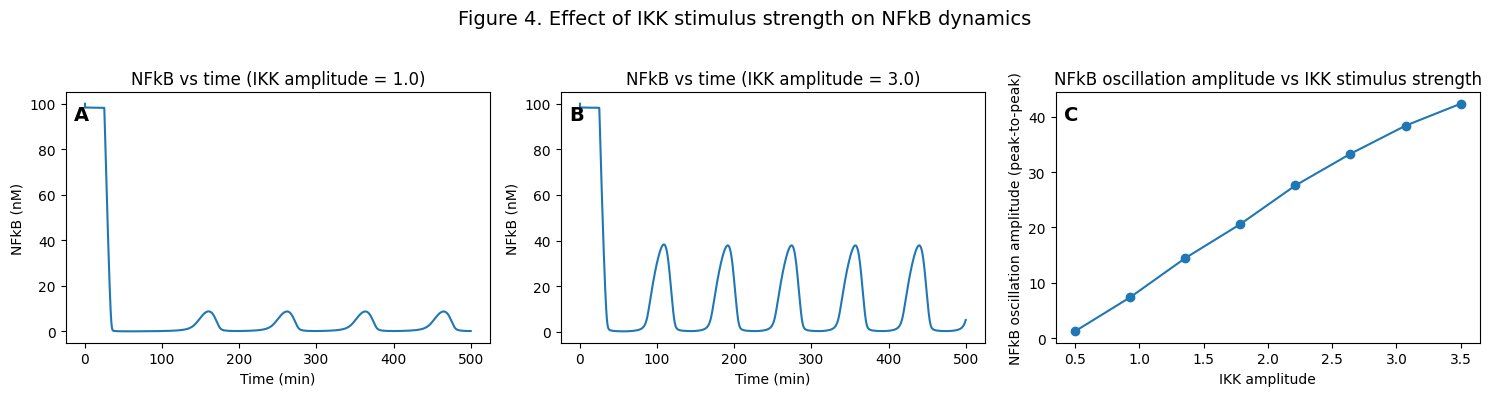

In [ ]:
# FIGURE 4 (A–C): Effect of IKK_amplitude
# 4A: NFkB time series for low IKK amplitude
# 4B: NFkB time series for high IKK amplitude
# 4C: NFkB oscillation amplitude vs IKK amplitude

# original IKK amplitude
IKK_amp_base = IKK_amplitude

IKK_low  = 1.0   # weaker stimulus than default
IKK_high = 3.0   # stronger stimulus than default

# Panel 4A: NFkB with low IKK amplitude
IKK_amplitude = IKK_low
t_low, sol_low = run_delay_sim(tau=tau_base, iterations=20)
NFKB_low = sol_low[:, 0]

# Panel 4B: NFkB with high IKK amplitude
IKK_amplitude = IKK_high
t_high, sol_high = run_delay_sim(tau=tau_base, iterations=20)
NFKB_high = sol_high[:, 0]

# Panel 4C: scan of IKK amplitude (dose–response)
IKK_amp_values = np.linspace(0.5, 3.5, 8)   # range of stimulus strengths
osc_amp_IKK = []

for IKK_val in IKK_amp_values:
    IKK_amplitude = IKK_val
    t_IKK, sol_IKK = run_delay_sim(tau=tau_base, iterations=20)
    amp = nfkb_oscillation_amplitude(t_IKK, sol_IKK, tau_base, windows_to_use=3)
    osc_amp_IKK.append(amp)

osc_amp_IKK = np.array(osc_amp_IKK)

# original IKK amplitude 
IKK_amplitude = IKK_amp_base

fig4, axes4 = plt.subplots(1, 3, figsize=(15, 4))
ax4A, ax4B, ax4C = axes4

# Panel 4A: NFkB with low IKK amplitude
ax4A.plot(t_low, NFKB_low)
ax4A.set_xlabel("Time (min)")
ax4A.set_ylabel("NFkB (nM)")
ax4A.set_title(f"NFkB vs time (IKK amplitude = {IKK_low:.1f})")

# Panel 4B: NFkB with high IKK amplitude
ax4B.plot(t_high, NFKB_high)
ax4B.set_xlabel("Time (min)")
ax4B.set_ylabel("NFkB (nM)")
ax4B.set_title(f"NFkB vs time (IKK amplitude = {IKK_high:.1f})")

# Panel 4C: oscillation amplitude vs IKK amplitude
ax4C.plot(IKK_amp_values, osc_amp_IKK, marker="o")
ax4C.set_xlabel("IKK amplitude")
ax4C.set_ylabel("NFkB oscillation amplitude (peak-to-peak)")
ax4C.set_title("NFkB oscillation amplitude vs IKK stimulus strength")

# Panel labels A, B, C
panel_labels = ["A", "B", "C"]
for ax, label in zip(axes4, panel_labels):
    ax.text(0.02, 0.95, label, transform=ax.transAxes,
            fontsize=14, fontweight="bold", va="top", ha="left")

fig4.suptitle("Figure 4. Effect of IKK stimulus strength on NFkB dynamics",
              fontsize=14)
fig4.tight_layout(rect=[0, 0.0, 1, 0.95])
fig4.savefig("figure4_IKK_dose_response.png", dpi=300, bbox_inches="tight")
plt.show()
